[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab3-GenAI-LLM/notebooks/01-introduction-genai.ipynb)

# Introduction to Generative AI

**ELMED219 / BMED365 - Lab 3**

Last updated: <br>
2025-12-21, A. Lundervold<br>
2026-01-02, 2026-01-18

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

| Objective | Description |
|-----------|-------------|
| **Explain generative AI** | Define GenAI and contrast with discriminative AI |
| **Trace historical development** | Identify key milestones from ELIZA to GPT-4o and beyond |
| **Understand LLM mechanics** | Explain token prediction and core concepts (context, temperature, etc.) |
| **Identify medical applications** | List clinical use cases with practical examples |
| **Recognize limitations** | Describe hallucination, bias, privacy risks, and liability issues |
| **Apply critical thinking** | Evaluate when and how to use AI responsibly in healthcare |

## Contents

1. [What is Generative AI?](#1-what-is-generative-ai)
2. [Historical Development](#2-historical-development)
3. [Large Language Models (LLM)](#3-large-language-models-llm)
4. [Applications in Medicine](#4-applications-in-medicine)
5. [Limitations and Challenges](#5-limitations-and-challenges)
6. [Summary](#6-summary)

---

## 1. What is Generative AI?

**Generative AI** (GenAI) refers to artificial intelligence systems that can *create new content* - whether text, images, audio, video, or code.

### Discriminative vs. Generative AI

| Type | What it does | Example |
|------|--------------|----------|
| **Discriminative AI** | Classifies or predicts based on input | "Is this X-ray normal or pathological?" |
| **Generative AI** | Creates new content based on patterns in training data | "Write a clinical note based on this consultation" |

### Key Characteristics of Generative AI

1. **Creativity**: Can produce original content not found in the training data
2. **Flexibility**: The same model can solve many different tasks
3. **Natural Language**: Communicates in human language (Norwegian, English, etc.)
4. **Contextual Understanding**: Takes into account context and previous information

### Reflection

> **Think about it**: Which tasks in your daily life (as a student or future healthcare worker) involve *creating* content vs. *classifying/evaluating* existing information?

---

### 💡 Self-Check Question 1

<details>
<summary>Click to reveal question</summary>

**Question:** A hospital wants to use AI for various tasks. Which of these is best suited for **generative AI** vs. **discriminative AI**?

A) Classify chest X-rays as normal/abnormal  
B) Generate patient discharge summaries from clinical notes  
C) Predict 30-day readmission risk from patient data  
D) Detect tumors in MRI scans

<details>
<summary>Click for answer</summary>

**Answer:** **B) Generate patient discharge summaries** is generative AI.

**Reasoning:**
- **A, C, D** are classification/prediction tasks → **Discriminative AI**
  - A: Binary classification (normal vs. abnormal)
  - C: Risk prediction (classification into risk categories)
  - D: Object detection/segmentation (locating tumors)
- **B** creates new content (text summary) → **Generative AI**
  - Takes clinical notes as input and generates a structured summary

> 🏥 **Clinical Connection:** Discriminative AI answers "what is this?" or "what category?" while generative AI answers "create this content." Both are valuable in healthcare but serve different purposes.

**Examples in practice:**
- **Discriminative:** ECG arrhythmia detection, diabetic retinopathy screening
- **Generative:** Clinical note summarization, patient education materials, radiology report generation
</details>
</details>

---

## 2. Historical Development

Generative AI has a long history, but in recent years there has been a revolution:

### Timeline

```
1950s        | Alan Turing: "Can machines think?"
             |
1960s        | ELIZA: Simple chatbot (pattern matching)
             |
1990s        | Statistical language models, n-grams
             |
2013         | Word2Vec: Words as vectors (embeddings)
             |
2017         | "Attention Is All You Need" - Transformer architecture
             |
2018         | BERT (Google) - Bidirectional Transformers
             |
2020         | GPT-3 (OpenAI) - 175 billion parameters
             |
2022         | ChatGPT launches - AI for everyone
             |
2023         | GPT-4, Claude 2, Gemini - Multimodal models
             |
2024-2025    | GPT-4o, Claude 3.5, DeepSeek-R1, open-source boom
```

### What Changed in 2017?

The paper ["Attention Is All You Need"](https://arxiv.org/abs/1706.03762) introduced the **transformer architecture**, which solved two critical problems:

1. **Parallelization**: Unlike previous models (RNN/LSTM), transformers can train on entire sequences simultaneously
2. **Long-range Dependencies**: The attention mechanism allows the model to "see" the entire context, not just recent information

This enabled training of much larger models on much more data.

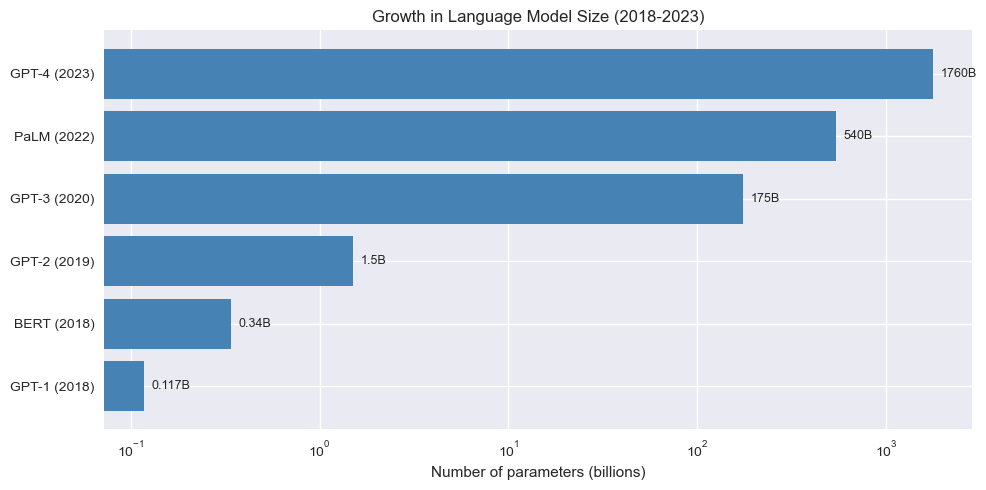

In [5]:
# =============================================================================
# ENVIRONMENT SETUP
# =============================================================================
# This cell sets up all required libraries for the notebook.
# Works in both local environment and Google Colab.

import sys

# -----------------------------------------------------------------------------
# Step 1: Check execution environment
# -----------------------------------------------------------------------------
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
else:
    print("Running in local environment")

# =============================================================================
# IMPORT REQUIRED LIBRARIES
# =============================================================================

# === Core Scientific Computing ===
import numpy as np                    # Numerical arrays and mathematical operations
import matplotlib.pyplot as plt       # Plotting and visualization

# =============================================================================
# REPRODUCIBILITY SETTINGS
# =============================================================================
# Setting random seed ensures consistent results across runs
# This is critical for scientific reproducibility

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)           # NumPy random operations
print(f"Random seed set to {RANDOM_SEED} for reproducibility")

# =============================================================================
# VISUALIZATION SETTINGS
# =============================================================================
# Use seaborn style if available, fall back gracefully if not
try:
    plt.style.use('seaborn-v0_8')     # matplotlib >= 3.6
except OSError:
    try:
        plt.style.use('seaborn')      # older matplotlib versions
    except OSError:
        pass  # Use default style if seaborn not available

print("\n✅ Environment is configured and ready!")

# =============================================================================
# VISUALIZATION: GROWTH IN MODEL SIZE
# =============================================================================
# This chart illustrates the exponential growth in LLM parameter count
# from 2018 to 2023, showing the scale-up that enabled today's capabilities

# Data: Model size (number of parameters in billions) over time
models = {
    'GPT-1 (2018)': 0.117,        # First GPT model
    'BERT (2018)': 0.34,          # Google's bidirectional transformer
    'GPT-2 (2019)': 1.5,          # Controversy over release due to capabilities
    'GPT-3 (2020)': 175,          # Breakthrough in few-shot learning
    'PaLM (2022)': 540,           # Google's Pathways Language Model
    'GPT-4 (2023)': 1760,         # Estimate (OpenAI hasn't disclosed exact size)
}

# Create horizontal bar chart with logarithmic scale
# Log scale needed because of exponential growth (0.1B to 1760B range)
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(list(models.keys()), list(models.values()), color='steelblue')
ax.set_xlabel('Number of parameters (billions)')
ax.set_title('Growth in Language Model Size (2018-2023)')
ax.set_xscale('log')                  # Logarithmic scale for better visualization

# Add parameter count labels to bars for readability
for i, (model, value) in enumerate(models.items()):
    ax.text(value * 1.1, i, f'{value}B', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---

### 💡 Self-Check Question 2

<details>
<summary>Click to reveal question</summary>

**Question:** Why was the 2017 Transformer architecture a breakthrough compared to previous models like RNN/LSTM?

<details>
<summary>Click for answer</summary>

**Answer:** The Transformer introduced two key innovations that revolutionized AI:

1. **Parallelization**: Unlike RNNs/LSTMs that process sequences word-by-word sequentially, transformers can process entire sequences simultaneously
   - **RNN/LSTM:** Must wait for word 1 before processing word 2, then word 3, etc.
   - **Transformer:** Can process all words at once using parallel computation
   - **Result:** Dramatically faster training (days instead of weeks/months)

2. **Attention Mechanism**: Can "see" and weigh the importance of all words in the entire context at once
   - **RNN/LSTM:** Limited memory; struggles with long-range dependencies
   - **Transformer:** Every word can directly attend to every other word
   - **Result:** Better understanding of context and relationships

**Impact on medical AI:**
- Enabled training of massive models (billions of parameters)
- Made it possible to process entire medical documents at once
- Better understanding of clinical context and relationships
- Foundation for models like GPT-4, Claude, and medical LLMs

**Visualization:**
```
RNN/LSTM:  word₁ → word₂ → word₃ → ... → wordₙ  (Sequential, slow)
Transformer: [word₁, word₂, word₃, ..., wordₙ]   (Parallel, fast)
              ↕️    ↕️    ↕️         ↕️
             All words attend to each other
```

> 📚 **Further Reading:** "Attention Is All You Need" (Vaswani et al., 2017) - [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)

> 🎥 **Recommended Video:** [3Blue1Brown's visual explanation](https://www.youtube.com/watch?v=wjZofJX0v4M) of attention and transformers
</details>
</details>

---

## 3. Large Language Models (LLM)

**Large Language Models (LLM)** are neural networks with billions of parameters, trained on enormous amounts of text from the internet, books, and other sources.

### How Do They Work?

At their core, LLMs do one thing: **predict the next word** (or *token*).

```
Input:  "The patient has fever and"
Output: "cough" (most likely next word)
```

By repeating this process thousands of times, the model can generate coherent text.

### Key Concepts

| Term | Explanation |
|--------|------------|
| **Token** | Smallest unit the model works with (often words or word parts) |
| **Context Window** | How much text the model can "remember" simultaneously |
| **Temperature** | Controls creativity vs. predictability |
| **Prompt** | The instruction/question you give the model |
| **Hallucination** | When the model "makes up" facts that are not true |

### Today's Leading Models

| Model | Developer | Strengths | Access |
|--------|----------|---------|----------|
| **GPT-4o** | OpenAI | Multimodal, fast | ChatGPT, API |
| **Claude 3.5** | Anthropic | Long context, safety | claude.ai, API |
| **Gemini** | Google | Integrated with Google services | gemini.google.com |
| **Llama 3** | Meta | Open source | Local execution |
| **DeepSeek-R1** | DeepSeek | Reasoning, open source | Local execution |

---

### 💡 Self-Check Question 3

<details>
<summary>Click to reveal question</summary>

**Question:** What is a "hallucination" in LLMs, and why is it particularly dangerous in medical applications?

<details>
<summary>Click for answer</summary>

**Answer:** 

**Hallucination Definition:**  
When an LLM generates text that sounds plausible and confident but is factually incorrect or completely fabricated.

**Why it happens:**
- LLMs predict the next token based on patterns, not facts
- No built-in fact-checking mechanism
- Trained to generate fluent text, not necessarily accurate text
- Can't distinguish between what it "knows" vs. what sounds right

**Medical Dangers:**

| Risk | Example | Consequence |
|------|---------|-------------|
| **Wrong dosages** | "Paracetamol: 100 mg/kg/day for children" (actual max: 60-75 mg/kg/day) | Patient harm, toxicity |
| **Incorrect diagnoses** | Confidently suggesting rare diseases for common symptoms | Unnecessary tests, anxiety, delayed treatment |
| **Fabricated citations** | Making up research papers that don't exist | Clinicians acting on non-existent evidence |
| **Drug interactions** | Missing critical interactions or inventing false ones | Adverse drug events |
| **False confidence** | Stating uncertain information as definite | Misplaced trust, clinical errors |

**Real-world medical hallucination examples:**
- ChatGPT inventing non-existent medical journals
- Suggesting medications not approved for certain conditions
- Providing outdated treatment guidelines with confidence
- Making up clinical trial results

**Mitigation Strategies:**

1. **Always verify** outputs against reliable sources (UpToDate, guidelines, Micromedex)
2. **Never use AI as sole decision-maker** - require human review
3. **Use specialized medical AI** with built-in safeguards when available
4. **Implement RAG** (Retrieval-Augmented Generation) to ground answers in verified databases
5. **Set confidence thresholds** - flag low-confidence outputs for review
6. **Cross-reference** with multiple sources
7. **Document AI use** in clinical decision-making for liability

> ⚠️ **Clinical Safety:** AI outputs must ALWAYS be validated by qualified healthcare professionals. Never act on AI suggestions without verification.

> 🔬 **Technical Note:** Hallucination is a fundamental limitation of current LLMs, not a bug to be fixed. It stems from the probabilistic nature of next-token prediction.
</details>
</details>

---

## 4. Applications in Medicine

Generative AI has the potential to transform many aspects of healthcare:

### Clinical Documentation
- **Automatic Charting**: Transcribe and structure consultations
- **Discharge Summary Generation**: Create summaries of hospital stays
- **Coding**: Suggest diagnosis codes (ICD-10) based on clinical text

### Clinical Decision Support
- **Differential Diagnosis**: Suggest possible diagnoses based on symptoms
- **Drug Interactions**: Check potential medication interactions
- **Summarization**: Summarize long patient records

### Patient Communication
- **Patient Information**: Explain diagnoses in patient-friendly language
- **Triage**: Assess urgency based on symptom descriptions
- **Follow-up**: Automate routine communication

### Research and Education
- **Literature Search**: Summarize research articles
- **Hypothesis Generation**: Suggest research questions
- **Simulated Patients**: Practice tools for students

### Example: Clinical Summary

**Input (long clinical text):**
```
03/15/2024: Patient presents for type 2 diabetes check-up. 
HbA1c 7.8%, up from 7.2% last time. Has stopped daily walks 
due to knee pain. Weight up 3 kg over last 3 months. Metformin 1000mg x2 
continues. Referring to physiotherapy for knee. Nutritional counseling offered.

03/22/2024: Phone call - asking about new tablets for diabetes. 
Informed to wait until next check-up. Satisfied with physiotherapy.

03/29/2024: Acute appointment - urinary tract infection. Dysuria and frequency. 
Urinalysis: Leukocytes+++, nitrite+. Pivmecillinam 200mg x3 for 5 days. 
Follow-up urine in 1 week.
```

**AI-generated summary:**
```
Type 2 diabetes patient with worsening glycemic control (HbA1c 7.8%) 
related to reduced physical activity due to knee pain. Weight gain 3 kg. 
Referred to physiotherapy and offered nutritional counseling. Treated for UTI 
in the meantime. Metformin continues unchanged.
```

---

## 5. Limitations and Challenges

Despite impressive capabilities, generative AI has significant limitations:

### Hallucination
LLMs can generate text that *sounds* correct but is actually wrong. This is especially dangerous in a medical context.

**Example:**
```
Question: "What is the standard dose of Paracetamol for children?"
AI answer: "Standard dose is 25 mg/kg every 4 hours, maximum 100 mg/kg/day."
                      ^
        WRONG! Correct maximum dose is 60-75 mg/kg/day
```

### Lack of Updated Knowledge
Models have a "knowledge cutoff" - they don't know about events after the training data was collected.

### Bias and Representation
Training data reflects historical biases that can affect advice on treatment, diagnoses, etc.

### Privacy
- Data sent to cloud services can be stored and used for training
- GDPR and health legislation set strict requirements for patient data

### Liability
Who is responsible if AI gives incorrect medical advice? The doctor? The hospital? The AI provider?

---

### 💡 Self-Check Question 4

<details>
<summary>Click to reveal question</summary>

**Question:** You want to use ChatGPT to summarize a patient's medical record. What is the PRIMARY concern, and what should you do instead?

<details>
<summary>Click for answer</summary>

**Answer:** **Privacy and GDPR compliance** is the primary concern.

### The Problem

**Critical issues when using public AI services (ChatGPT, Claude, etc.) with patient data:**

| Issue | Explanation | Legal Impact |
|-------|-------------|--------------|
| **Data leaves your control** | Sent to external servers (often outside EU/Norway) | GDPR violation |
| **Storage and training** | Data may be stored and used to train future models | Patient consent violation |
| **No data processing agreement (DPA)** | Required by GDPR for processing personal data | Illegal processing |
| **Lack of transparency** | Unknown how data is processed, stored, or secured | Breach of accountability |
| **Cross-border transfer** | Data may cross borders without adequate safeguards | GDPR Article 44-50 violation |

### Real Consequences

- **Fines:** Up to €20 million or 4% of annual turnover (GDPR)
- **Criminal liability:** Personal liability for healthcare workers
- **Patient harm:** Confidential information disclosure
- **License revocation:** Professional consequences for doctors
- **Organizational damage:** Loss of trust, reputation damage

### What Norwegian Law Says

- **Pasientjournalloven:** Strict requirements for electronic patient records
- **Helseregisterloven:** Governs health data registries
- **GDPR (Personvernforordningen):** Applies to all personal data
- **Helsepersonelloven:** Healthcare workers' duty of confidentiality

### Safe Alternatives

| Solution | Description | When to Use |
|----------|-------------|-------------|
| **Local/On-premises LLMs** | Run models on hospital servers (e.g., Ollama, local Llama) | High sensitivity data |
| **Enterprise AI with DPA** | Azure OpenAI, AWS Bedrock with signed agreements | Approved by IT/legal |
| **Anonymization** | Remove all identifying information first | Lower sensitivity tasks |
| **Synthetic data** | Use realistic but fake patient scenarios for testing | Training and education |
| **Approved clinical AI** | Use validated, CE-marked medical AI tools | Clinical decision support |

### Practical Checklist Before Using AI

Before using any AI tool with patient data, ask:

- [ ] Is there a signed data processing agreement (DPA)?
- [ ] Does the tool have necessary approvals (CE mark, FDA, etc.)?
- [ ] Where is the data processed and stored?
- [ ] Can data be deleted on request?
- [ ] Is the data encrypted in transit and at rest?
- [ ] Has the hospital's IT/security approved the tool?
- [ ] Would I feel comfortable if this patient found out?

> 🔒 **Privacy First:** Never share identifiable patient data with public AI services without proper legal agreements. When in doubt, assume it's not allowed.

> ⚖️ **Legal Reminder:** "I didn't know" is not a valid defense under GDPR. Healthcare workers are personally responsible for patient data protection.

> 💡 **Practical Tip:** For learning and testing, create realistic synthetic patient scenarios instead of using real data. This is perfectly legal and safe for educational purposes.
</details>
</details>

### Important Reminders

> **AI does NOT replace clinical judgment.** All AI-generated suggestions must be validated by qualified healthcare professionals.

> **Privacy first.** Never share real patient data with AI services without an approved data processing agreement.

> **Be critical.** AI can "hallucinate" - always verify facts against reliable sources.

---

## 🎯 Summary: Key Takeaways

### The Big Picture

```mermaid
flowchart LR
    TrainingData[Training Data<br/>Internet books papers] --> Transformer[Transformer<br/>Architecture 2017]
    Transformer --> LLM[Large Language Model<br/>Billions of parameters]
    LLM --> NextToken[Predict Next Token]
    NextToken --> Output[Generated Text]
    Output --> Applications[Medical Applications]
    
    Applications --> Doc[Documentation]
    Applications --> Decision[Decision Support]
    Applications --> Patient[Patient Communication]
    
    Limitations[Limitations] -.-> Output
    Limitations --> Hallucination
    Limitations --> Privacy
    Limitations --> Bias
```

### Core Concepts

| # | Concept | Key Insight | Remember This |
|---|---------|-------------|---------------|
| 1 | **GenAI creates, Discriminative AI classifies** | Different AI types for different tasks | Know which tool for which job |
| 2 | **Transformers revolutionized AI (2017)** | Attention + parallelization = scale | Foundation of all modern LLMs |
| 3 | **LLMs predict next token** | Simple principle, powerful results | Trained on massive text corpora |
| 4 | **Context window = memory limit** | Models can't "remember" beyond this limit | GPT-4: ~96k words |
| 5 | **Hallucination is a fundamental risk** | LLMs can confidently state falsehoods | Always verify medical outputs |
| 6 | **Privacy is paramount** | GDPR applies to all patient data | Never share real data with public AI |
| 7 | **Medical AI needs validation** | AI assists, humans decide | Regulatory approval required |
| 8 | **Bias reflects training data** | Historical inequalities propagate | Requires careful monitoring |

### Medical AI Applications

| Use Case | Example | Status | Risk Level |
|----------|---------|--------|------------|
| **Documentation** | Auto-generate discharge summaries | In use (some hospitals) | Medium |
| **Literature Search** | Summarize research papers | Widely used | Low |
| **Patient Communication** | Explain diagnoses in plain language | Emerging | Medium |
| **Clinical Decision Support** | Suggest differential diagnoses | Research phase | **High** ⚠️ |
| **Drug Interaction Checking** | Flag potential interactions | In use | **High** ⚠️ |
| **Medical Education** | Simulated patient conversations | Emerging | Low |
| **Radiology Reporting** | Generate draft reports from images | Pilot programs | **High** ⚠️ |
| **ICD-10 Coding** | Suggest diagnosis codes from notes | Emerging | Medium |

### Historical Timeline (Key Milestones)

```
1960s  → ELIZA: First chatbot (pattern matching)
2013   → Word2Vec: Word embeddings
2017   → Transformer architecture (breakthrough)
2018   → BERT, GPT-1: First transformer LLMs
2020   → GPT-3: 175B parameters, few-shot learning
2022   → ChatGPT launch: AI for everyone
2023   → GPT-4, Claude 2: Multimodal capabilities
2024-25→ GPT-4o, Claude 3.5, DeepSeek-R1: Open-source boom
```

### What You Can Now Explain

After completing this notebook, you should be able to answer:

- ✅ "What's the difference between generative and discriminative AI?"
- ✅ "Why was 2017 a turning point for AI?"
- ✅ "How do LLMs actually work at a basic level?"
- ✅ "What are realistic medical applications of LLMs today?"
- ✅ "What are the main risks of using AI in healthcare?"
- ✅ "Why can't I just use ChatGPT with patient data?"
- ✅ "What is hallucination and why is it dangerous in medicine?"
- ✅ "How has model size grown from 2018 to 2023?"

### Critical Safety Principles

> ⚠️ **Never replace clinical judgment** - AI is a tool, not a decision-maker

> 🔒 **Privacy first** - No patient data in public AI services without DPA

> ✓ **Always verify** - Check AI outputs against reliable sources

> 📋 **Document AI use** - Keep records for liability and quality assurance

> 👥 **Human-in-the-loop** - Require qualified review of all clinical AI outputs

### Next Steps

In the following notebooks we will dive deeper into:

| Notebook | Topic | What You'll Learn |
|----------|-------|-------------------|
| **02** | [Transformer Architecture](02-transformer-architecture.ipynb) | How attention mechanism works in detail |
| **03** | [LLM Fundamentals](03-llm-fundamentals.ipynb) | Tokens, temperature, context window, embeddings |
| **04** | [Prompt Engineering](04-prompt-engineering.ipynb) | Techniques for effective AI communication |
| **05** | [Explainable AI (XAI)](05-xai-explainable-ai.ipynb) | Understanding what AI "sees" and why |
| **06** | [AI Ethics in Medicine](06-ai-ethics-medicine.ipynb) | Bias, fairness, and responsible AI |

---

## 📚 Glossary of Key Terms

| Term | Definition | Example/Context |
|------|------------|-----------------|
| **Attention Mechanism** | Technique allowing models to focus on relevant parts of input | Core innovation in Transformers (2017) |
| **BERT** | Bidirectional Encoder Representations from Transformers | Google's model for understanding context |
| **Bias** | Systematic errors in AI reflecting training data biases | Historical biases in medical treatment recommendations |
| **Context Window** | Maximum text length a model can process at once | GPT-4: 128k tokens (~96k words) |
| **Discriminative AI** | AI that classifies or predicts | "Is this X-ray normal or abnormal?" |
| **ELIZA** | Early chatbot (1960s) using pattern matching | First attempt at conversational AI |
| **Embedding** | Numerical representation of words/tokens as vectors | Word2Vec (2013) converted words to numbers |
| **Fine-tuning** | Training pre-trained model on specific task | Adapting GPT for medical terminology |
| **Generative AI** | AI that creates new content | Text, images, audio, code generation |
| **GPT** | Generative Pre-trained Transformer | OpenAI's language model family |
| **Hallucination** | AI generating plausible but false information | Made-up drug dosages or citations |
| **Knowledge Cutoff** | Latest date of training data | GPT-4: April 2023; no newer knowledge |
| **LLM** | Large Language Model | Neural network with billions of parameters |
| **LTD** | Long-Term Depression | Weakening of synapses (biological learning) |
| **LTP** | Long-Term Potentiation | Strengthening of synapses (biological learning) |
| **Multimodal** | Handling multiple data types (text, images, audio) | GPT-4V can analyze medical images |
| **Parameter** | Learnable weight in neural network | GPT-3: 175B, GPT-4: ~1.7T (estimated) |
| **Prompt** | Input instruction given to LLM | "Summarize this clinical note" |
| **Prompt Engineering** | Crafting effective prompts for desired outputs | Zero-shot, few-shot, chain-of-thought |
| **RAG** | Retrieval-Augmented Generation | Combining LLM with database search to reduce hallucination |
| **RNN/LSTM** | Recurrent/Long Short-Term Memory networks | Sequential models before Transformers |
| **Temperature** | Controls randomness/creativity of output | Low (0.2) = focused; High (0.8) = creative |
| **Token** | Basic unit of text processing | ~0.75 words on average in English |
| **Transformer** | Neural architecture using attention | Foundation of modern LLMs since 2017 |
| **Zero-shot** | Performing task without specific training examples | "Translate this to Norwegian" without examples |
| **Few-shot** | Learning from a few examples in the prompt | Providing 2-3 examples before the task |
| **Chain-of-Thought** | Prompting technique asking model to show reasoning | "Let's think step by step..." |

### Medical AI Specific Terms

| Term | Definition | Clinical Relevance |
|------|------------|-------------------|
| **CE Mark** | European conformity certification | Required for medical devices in EU |
| **Clinical Decision Support (CDS)** | Systems assisting clinical decisions | High-risk AI requiring validation |
| **Data Processing Agreement (DPA)** | Legal contract for personal data handling | Required under GDPR |
| **Differential Diagnosis** | List of possible diagnoses for symptoms | AI can suggest, but doctor decides |
| **FDA Approval** | US regulatory approval for medical devices | Required for clinical AI in USA |
| **GDPR** | General Data Protection Regulation | EU privacy law governing patient data |
| **ICD-10** | International Classification of Diseases | Standard diagnostic codes |
| **Triage** | Assessment of urgency/priority | AI can assist in emergency departments |
| **Synthetic Data** | Artificially generated realistic data | Safe for AI training without privacy risk |

> 💡 **Study Tip:** Review this glossary before exams or when encountering unfamiliar terms in later notebooks.

---

## 📖 Further Reading & Resources

### Essential Papers

| Paper | Why It's Important | Link |
|-------|-------------------|------|
| **Attention Is All You Need** (Vaswani et al., 2017) | Introduced Transformer architecture - foundation of all modern LLMs | [arXiv:1706.03762](https://arxiv.org/abs/1706.03762) |
| **Language Models are Few-Shot Learners** (Brown et al., 2020) | GPT-3 paper demonstrating few-shot learning at scale | [arXiv:2005.14165](https://arxiv.org/abs/2005.14165) |
| **BERT: Pre-training of Deep Bidirectional Transformers** (Devlin et al., 2018) | Bidirectional transformers for language understanding | [arXiv:1810.04805](https://arxiv.org/abs/1810.04805) |
| **Towards Expert-Level Medical Question Answering with LLMs** (Singhal et al., 2023) | Comprehensive review of LLMs in medicine (Med-PaLM 2) | [Nature](https://www.nature.com/articles/s41586-023-06291-2) |
| **Large Language Models Encode Clinical Knowledge** (Singhal et al., 2022) | Original Med-PaLM paper on medical Q&A | [arXiv:2212.13138](https://arxiv.org/abs/2212.13138) |

### Video Tutorials (Highly Recommended)

| Resource | Description | Duration | Link |
|----------|-------------|----------|------|
| **3Blue1Brown: Visualizing Attention** | Beautiful visual explanation of transformers and attention | ~20 min | [YouTube](https://www.youtube.com/watch?v=wjZofJX0v4M) |
| **StatQuest: Transformers Clearly Explained** | Step-by-step breakdown with simple examples | ~15 min | [YouTube](https://www.youtube.com/watch?v=zxQyTK8quyY) |
| **Andrej Karpathy: GPT from Scratch** | Build a mini-GPT (advanced, but excellent) | ~2 hours | [YouTube](https://www.youtube.com/watch?v=kCc8FmEb1nY) |
| **Two Minute Papers: Latest LLM Advances** | Quick updates on newest developments | ~5 min each | [YouTube Channel](https://www.youtube.com/@TwoMinutePapers) |

### Online Courses

| Course | Provider | Description | Level | Link |
|--------|----------|-------------|-------|------|
| **ChatGPT Prompt Engineering for Developers** | DeepLearning.AI | Official prompt engineering course by Andrew Ng | Beginner | [Course](https://www.deeplearning.ai/short-courses/chatgpt-prompt-engineering-for-developers/) |
| **Practical Deep Learning** | Fast.ai | Hands-on, top-down approach to deep learning | Intermediate | [Course](https://course.fast.ai/) |
| **Natural Language Processing with Deep Learning** | Stanford CS224N | Comprehensive NLP course | Advanced | [Course](http://web.stanford.edu/class/cs224n/) |
| **Hugging Face NLP Course** | Hugging Face | Free course on transformers and NLP | Beginner-Int | [Course](https://huggingface.co/learn/nlp-course) |

### Tools & Platforms

| Tool | Purpose | Cost | Link |
|------|---------|------|------|
| **OpenAI Playground** | Experiment with GPT models | Pay-per-use | [platform.openai.com](https://platform.openai.com/playground) |
| **Anthropic Claude** | Alternative to ChatGPT with long context | Free/Pro | [claude.ai](https://claude.ai) |
| **Google Gemini** | Google's multimodal LLM interface | Free/Pro | [gemini.google.com](https://gemini.google.com) |
| **Ollama** | Run LLMs locally on your computer | Free | [ollama.ai](https://ollama.ai) |
| **HuggingFace** | Open-source model repository and tools | Free | [huggingface.co](https://huggingface.co) |
| **LM Studio** | User-friendly local LLM interface | Free | [lmstudio.ai](https://lmstudio.ai) |
| **Perplexity AI** | AI search engine with citations | Free/Pro | [perplexity.ai](https://www.perplexity.ai) |

### Medical AI Specific Resources

| Resource | Description | Link |
|----------|-------------|------|
| **WHO Guidance on Large Language Models** | Ethics and governance of LLMs in health | [WHO](https://www.who.int/publications/i/item/9789240084759) |
| **FDA AI/ML Software as Medical Device** | Regulatory framework for medical AI in USA | [FDA](https://www.fda.gov/medical-devices/software-medical-device-samd/artificial-intelligence-and-machine-learning-aiml-enabled-medical-devices) |
| **EU AI Act** | European regulation on high-risk AI systems | [EU AI Act](https://artificialintelligenceact.eu/) |
| **Medical AI Safety Repository** | Database of AI safety issues in healthcare | [Stanford](https://dho.stanford.edu/) |
| **MONAI** | PyTorch-based medical imaging AI framework | [MONAI](https://monai.io/) |
| **ClinicalBERT** | BERT fine-tuned on clinical notes | [Paper](https://arxiv.org/abs/1904.05342) |

### Books

| Book | Author | Description | Level |
|------|--------|-------------|-------|
| **The Alignment Problem** | Brian Christian | AI safety, ethics, and alignment challenges | General |
| **AI 2041: Ten Visions for Our Future** | Kai-Fu Lee & Chen Qiufan | Future scenarios for AI in society | General |
| **Architects of Intelligence** | Martin Ford | Interviews with 23 AI pioneers | General |
| **Deep Learning** | Goodfellow, Bengio, Courville | The "bible" of deep learning (technical) | Advanced |
| **Natural Language Processing with Transformers** | Tunstall, von Werra, Wolf | Practical guide to transformers with Hugging Face | Intermediate |

### Community & Newsletters

| Resource | Description | Frequency |
|----------|-------------|-----------|
| **The Batch** (DeepLearning.AI) | AI news and insights from Andrew Ng | Weekly |
| **Import AI** | AI research and policy updates | Weekly |
| **TLDR AI** | Quick AI news summary | Daily |
| **r/MachineLearning** | Reddit community for ML research | Ongoing |
| **r/LocalLLaMA** | Running LLMs locally | Ongoing |

### Reflection Exercise

After reviewing this material, reflect on these questions:

1. **Opportunities**: Name three specific tasks in healthcare where generative AI can save time or improve quality.

2. **Risk**: What is the potentially most dangerous consequence of blindly trusting AI in clinical practice?

3. **Future**: How do you think the relationship between physician and AI will evolve over the next 10 years?

---

## 💬 Group Discussion Questions

Use these questions for small group discussions (2-3 students, 10-15 minutes each):

### Discussion 1: The Hallucination Dilemma
> "A medical student uses ChatGPT to look up a drug dosage and the AI confidently provides incorrect information. The student doesn't verify it."

- Who is responsible if this leads to patient harm?
- Should medical students be allowed to use AI for clinical information?
- How would you design a system to prevent such errors?

### Discussion 2: The Transparency Question
> "Your hospital implements an AI system that flags high-risk patients. It works well, but no one can explain exactly why it makes certain predictions."

- Should patients be told when AI was involved in their care?
- Would you trust an AI recommendation you couldn't understand?
- How much explainability is "enough" for clinical use?

### Discussion 3: The Future Physician
> "By 2035, AI can diagnose most conditions more accurately than physicians. Medical school applications drop significantly."

- What uniquely human skills should physicians preserve?
- How should medical education change to prepare for this future?
- What is the physician's role when AI is "better" at diagnosis?

### Discussion 4: Norwegian Healthcare Context
> "Helse Vest wants to implement an AI system for radiology triage. The system was trained primarily on data from US hospitals."

- What concerns would you raise about using this system in Norway?
- How might Norwegian patient demographics differ from the training data?
- What validation would you require before deployment?

### Peer Teaching Exercise

**Task**: In pairs, take turns explaining one concept to your partner as if they were a patient asking about AI in healthcare:
1. Partner A explains: "What is ChatGPT and can my doctor use it?"
2. Partner B explains: "Why might the AI sometimes be wrong?"

Swap roles and discuss: What was hardest to explain in simple terms?

---

## 🙏 Acknowledgments

This notebook was created for **BMED365/ELMED219** at the University of Bergen. Medical analogies and clinical examples are designed to help healthcare students understand generative AI through familiar contexts.

**Learning Resources:**
- Lab structure inspired by fast.ai pedagogical approach
- Medical examples contextualized for Norwegian healthcare system
- Self-check questions designed to reinforce key concepts
- Resources curated for medical/healthcare learners

**Contributors:**
- Course design: A. Lundervold
- Medical context review: ELMED219/BMED365 teaching team
- Student feedback incorporated from 2024-2025 cohorts

---

*Next notebook: [02 - Transformer Architecture](02-transformer-architecture.ipynb)*

*Last updated: 2026-01-18*